In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("retail_sales.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Observation

- The dataset was loaded successfully.
- The first five records provide an overview of customer transactions and available features.

In [6]:
df.shape

(1000, 9)

## Observation

- The dataset contains 1000 rows and 9 columns.
- This indicates that sufficient data is available for exploratory analysis.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [8]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [10]:
print(df.mean(numeric_only=True))
print(df.median(numeric_only=True))
print(df.mode().iloc[0])
print(df.std(numeric_only=True))

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64
Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [11]:
df["Date"] = pd.to_datetime(df["Date"])

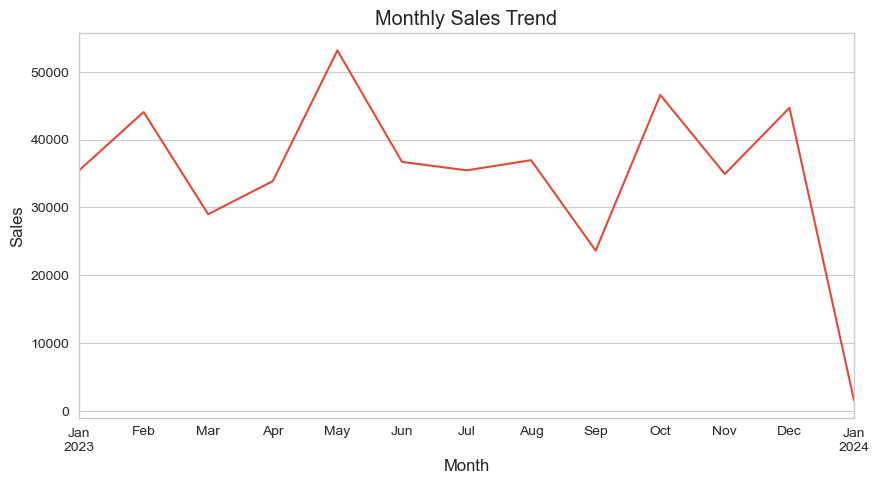

In [12]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

### Observation

- Monthly sales fluctuate throughout the year, showing both increases and decreases.
- The highest sales were recorded in **May 2023**, while **September 2023** had the lowest sales among the full months.
- Sales recovered during **October to December 2023** after the decline in September.
- The sharp drop in **January 2024** is likely due to incomplete data for that month.

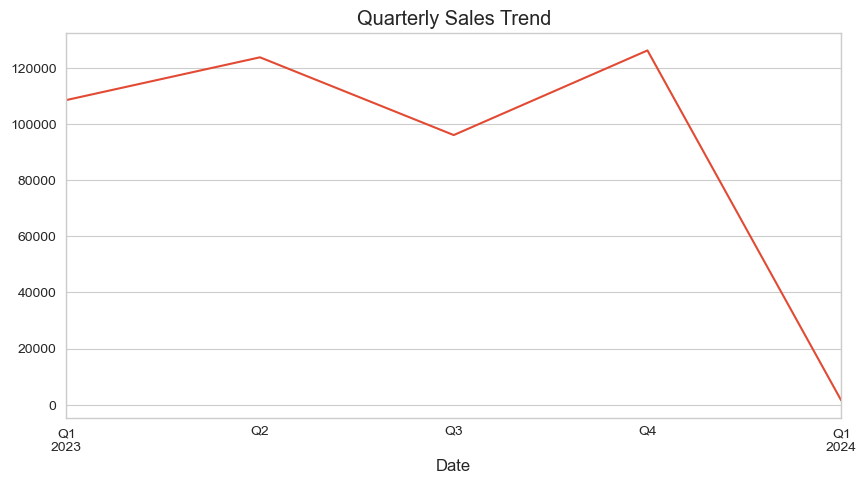

In [13]:
quarterly_sales = df.groupby(df["Date"].dt.to_period("Q"))["Total Amount"].sum()

quarterly_sales.plot(figsize=(10,5))

plt.title("Quarterly Sales Trend")
plt.show()

### Observation

- Sales increased from **Q1 2023** to **Q2 2023**.
- Sales decreased in **Q3 2023** and recovered in **Q4 2023**.
- Sales dropped sharply in **Q1 2024**, likely because the dataset contains only partial data for that quarter.

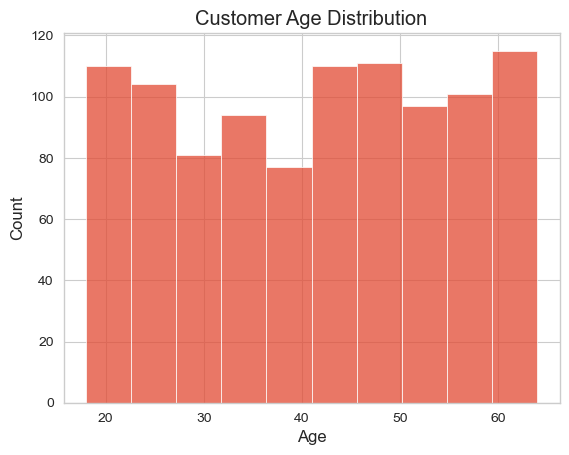

In [14]:
sns.histplot(df["Age"], bins=10)

plt.title("Customer Age Distribution")
plt.show()

### Observation

- Customers are spread across the age range of approximately **18 to 64 years**.
- Most customers appear to belong to the **40–60 years** age group, as this range has relatively higher frequencies.
- The dataset includes customers from a wide range of ages, indicating purchases are made by both younger and older customers.

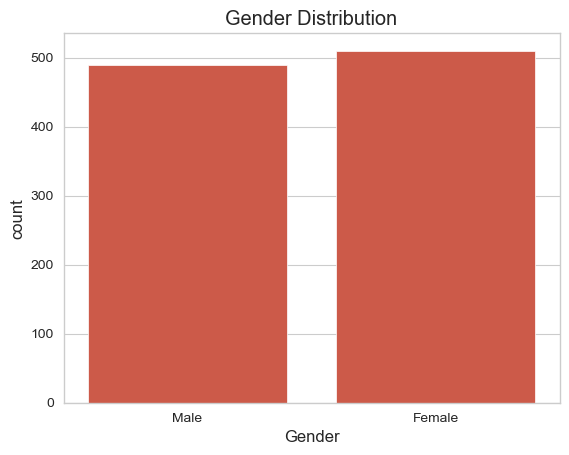

In [15]:
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.show()

### Observation

- The number of **male** and **female** customers is almost equal.
- **Female customers** are slightly higher in number than male customers.
- This indicates that the customer base is well-balanced across both genders, with no significant gender imbalance.

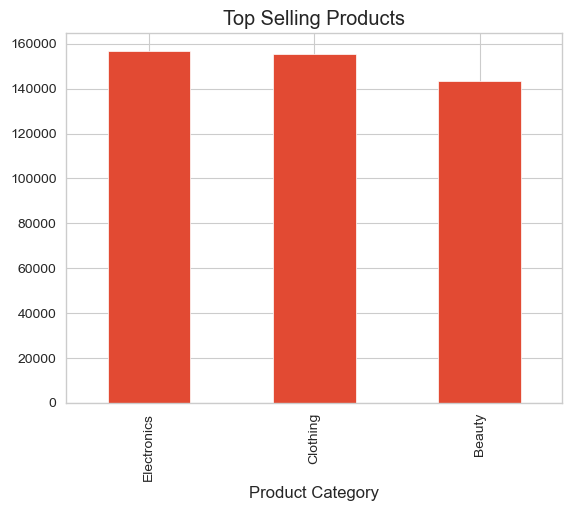

In [16]:
top_products = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

top_products.head(10).plot(kind="bar")

plt.title("Top Selling Products")
plt.show()

### Observation

- **Electronics** is the top-selling product category with the highest total sales.
- **Clothing** ranks second, with sales slightly lower than Electronics.
- **Beauty** has the lowest sales among the three product categories.
- The sales difference between the categories is relatively small, indicating balanced customer demand across all product categories.

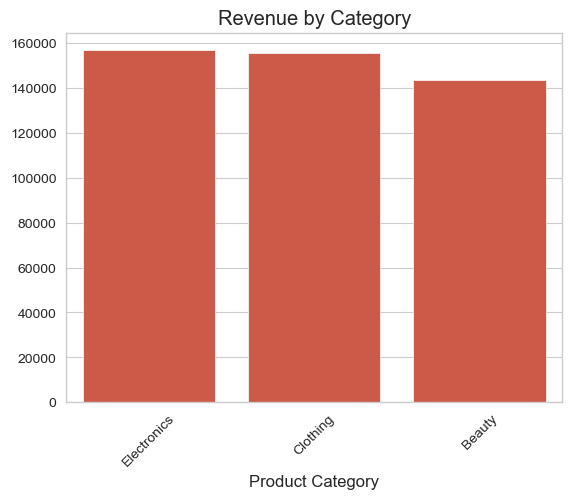

In [17]:
sns.barplot(
    x=top_products.index,
    y=top_products.values
)

plt.xticks(rotation=45)

plt.title("Revenue by Category")

plt.show()

### Observation

- **Electronics** generated the highest revenue among all product categories.
- **Clothing** contributed the second-highest revenue, slightly lower than Electronics.
- **Beauty** generated the lowest revenue compared to the other categories.
- Overall, revenue is fairly balanced across all three categories, with Electronics making the largest contribution.

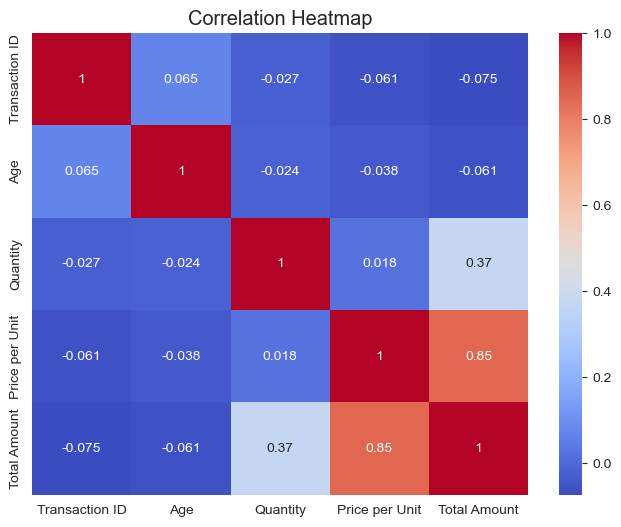

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- **Price per Unit** has a **strong positive correlation (0.85)** with **Total Amount**, indicating that higher-priced products generate higher revenue.
- **Quantity** has a **moderate positive correlation (0.37)** with **Total Amount**, showing that purchasing more items increases the total sales amount.
- **Age** and **Transaction ID** have very weak or no significant correlation with the other variables.
- Overall, **Price per Unit** is the strongest factor influencing the **Total Amount**.

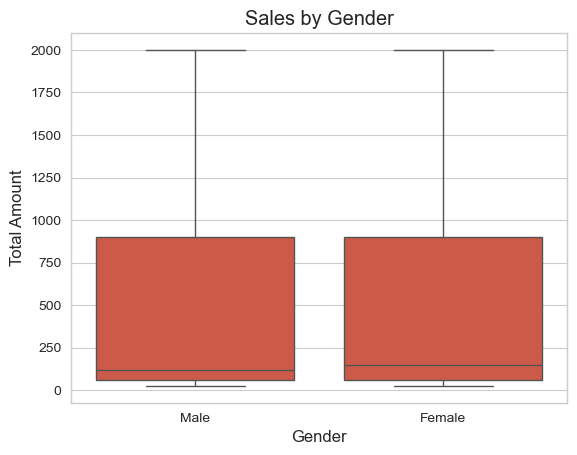

In [19]:
sns.boxplot(
    x="Gender",
    y="Total Amount",
    data=df
)

plt.title("Sales by Gender")

plt.show()

### Observation

- The distribution of sales is very similar for both **male** and **female** customers.
- The median sales amount is nearly the same for both genders, indicating similar spending behavior.
- Both genders show a wide range of purchase amounts, from low-value to high-value transactions.
- Overall, there is no significant difference in sales between male and female customers.

Conclusion

1. Focus marketing on the highest revenue product category.

2. Increase inventory during high sales months.

3. Offer personalized promotions for the most active customer age group.